Data Understand and EDA
- Rohan

Tab used eventually: 23-25_data_updated

In [90]:
import pandas as pd

# Load the Excel file
file_path = "C:/Users/rohan/Downloads/TOUCHABLE CHAPA Chapter 40B Application Data 2021-2023 & 10_2023-05_2025.xlsx"

# List all sheet names
sheet_names = pd.ExcelFile(file_path).sheet_names
print("Available Sheets:")
for s in sheet_names:
    print("-", s)

Available Sheets:
- 2023-2025
- Saniya 2023-2025
- Clean Saniya 2023-2025
- Copy Clean Saniya 23-25
- 23-25_data_updated
- NEW 2023-2025
- 2021-2023
- CLEAN Kayla 2021-2023
- Copy of CLEAN Kayla 2021-2023
- Geocoded Kayla 2021-2023
- Kayla Working 2021-2023
- Kayla 2021-2023 Working 2.0
- CLEAN w stats Kayla 2021-2023


Step 1: Load and Inspect Dataset Sheets (2023–2025)

Previewing and comparing multiple worksheet versions to identify the most complete dataset for analysis.

In [91]:
# Load specific sheets into a dictionary of DataFrames
manual_sheets = [
    "2023-2025",
    "Copy Clean Saniya 23-25",
    "23-25_data_updated",
    "NEW 2023-2025"
]

data_dict = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in manual_sheets}

for sheet, df in data_dict.items():
    print(f"\nData from sheet: {sheet}")
    print(df.head(2))
    print("Shape:", df.shape)


Data from sheet: 2023-2025
   ID Number             Submission Date    Application Property      Source  \
0     314921  2023-10-21 19:05:21.175000        Groton, 503 Main  MyMassHome   
1     827042  2023-10-24 20:41:07.886000  North Andover Unit 109  MyMassHome   

    Age        Race/Ethnicity Disability Current Residence  HH Size  \
0  44.0  Choose not to answer         No         Watertown        2   
1  32.0                 White         No     Haverhill, MA        1   

   Dependents        HH Type  HH Income  HH Assets FTHB Class?  
0           0  Single person    60000.0       2.00         Yes  
1           0  Single person    62608.0   26866.69         Yes  
Shape: (1360, 14)

Data from sheet: Copy Clean Saniya 23-25
   ID Number Submission Date  Submission Time   \
0        101       2024-05-28         13:31:01   
1        101       2024-07-21         17:33:34   

                    Application Property Application City/Town  \
0   14 Caspian Way, Unit 23 ~ Leominster     

In [92]:
# Summarize all loaded sheets
summary = {sheet: df.shape for sheet, df in data_dict.items()}
pd.DataFrame(summary, index=['Rows', 'Columns'])

,2023-2025,Copy Clean Saniya 23-25,23-25_data_updated,NEW 2023-2025
Rows,1360,1360,1359,1360
Columns,14,20,29,14


In [93]:
# Check for unique columns in each sheet
for sheet, df in data_dict.items():
    print(f"\n{sheet} — unique columns:", len(df.columns))
    print(df.columns.tolist())


2023-2025 — unique columns: 14
['ID Number', 'Submission Date', 'Application Property', 'Source', 'Age', 'Race/Ethnicity', 'Disability', 'Current Residence', 'HH Size', 'Dependents', 'HH Type', 'HH Income', 'HH Assets', 'FTHB Class?']

Copy Clean Saniya 23-25 — unique columns: 20
['ID Number', 'Submission Date ', 'Submission Time ', 'Application Property', 'Application City/Town', 'Application St Address', 'Application Unit', 'Source New', 'Age', 'Race Combination Normalized', 'Census Races', 'Disability', 'Current Residence Town/City', 'Current Residence State ', 'HH Size', 'Dependents', 'HH Type Standardized', 'HH Income', 'HH Assets', 'FTHB Class?']

23-25_data_updated — unique columns: 29
['ID Number', 'Submission Date', 'Submission Time', 'Application Property', 'Application City/Town', 'Application St Address', 'Application Unit', 'Source New', 'Age', 'Race Combination Normalized', 'Census Races', 'Disability', 'Current Residence Town/City', 'Current Residence State', 'HH Size',

In [94]:
for sheet, df in data_dict.items():
    print(f"\n---- Structure check: {sheet} ----")
    print(df.info())
    print(f"\n---- Null values check: {sheet} ----")
    print(df.isnull().sum())

    # Optional: show top 10 missing % for context
    print("\nTop 10 Missing Values (%):")
    print((df.isnull().mean() * 100).sort_values(ascending=False).head(10))



---- Structure check: 2023-2025 ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1360 entries, 0 to 1359
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID Number             1360 non-null   int64  
 1   Submission Date       1360 non-null   object 
 2   Application Property  1359 non-null   object 
 3   Source                1356 non-null   object 
 4   Age                   1359 non-null   float64
 5   Race/Ethnicity        1357 non-null   object 
 6   Disability            1358 non-null   object 
 7   Current Residence     1359 non-null   object 
 8   HH Size               1360 non-null   int64  
 9   Dependents            1360 non-null   int64  
 10  HH Type               1360 non-null   object 
 11  HH Income             1355 non-null   float64
 12  HH Assets             1359 non-null   float64
 13  FTHB Class?           1357 non-null   object 
dtypes: float64(3), int64(3), object(8)

Structure & Missing Value Overview

After inspecting all 2023–25 dataset versions:

- **`23–25_data_updated`** has the most complete structure (29 columns), including geocoding (`Match Type`, `Matched Address`, `MSA`) and unique applicant IDs.
- **Key missing data:**
  - `ZIP`: 100 % missing — expected, replaced by matched address information.
  - `Application Unit`: ~56 % missing — not every property has a unit number.
  - `Match Type` / `Matched Address`: ~11 % missing — likely un-matched addresses.
  - Other variables (`Source New`, `Disability`, `FTHB Class?`) have < 2 % missing values.
- Earlier sheets (2023–2025, NEW 2023–2025) show similar schemas but fewer fields, confirming this dataset’s evolution through cleaning.


In [95]:
df = data_dict["23-25_data_updated"].copy()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')


print(df.info())
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_number                    1359 non-null   int64         
 1   submission_date              1359 non-null   datetime64[ns]
 2   submission_time              1359 non-null   object        
 3   application_property         1359 non-null   object        
 4   application_city_town        1359 non-null   object        
 5   application_st_address       1359 non-null   object        
 6   application_unit             594 non-null    object        
 7   source_new                   1335 non-null   object        
 8   age                          1358 non-null   float64       
 9   race_combination_normalized  1359 non-null   object        
 10  census_races                 1359 non-null   object        
 11  disability                   1357 non-null 

In [96]:
df =df.drop(columns=['zip'])
fill_values = {
    'match_type': 'Unknown',
    'matched_address': 'Unknown',
    'source_new': 'Unknown',
    'disability': 'Unknown',
    'current_residence_town_city': 'Unknown',
    'current_residence_state': 'Unknown',
    'fthb_class?': 'Unknown'
}
df = df.fillna(fill_values)

df['hh_income'] = df['hh_income'].fillna(df['hh_income'].median())

print(df.isnull().sum().sort_values(ascending=False).head(10))

application_unit               765
age                              1
hh_assets                        1
id_number                        0
application_property             0
submission_time                  0
application_st_address           0
application_city_town            0
source_new                       0
race_combination_normalized      0
dtype: int64


In [97]:
print("📊 Numeric Columns Summary:\n")
print(df.describe())

print("\n🧠 Data Types Overview:")
print(df.dtypes.value_counts())

categorical_cols = df.select_dtypes(include='object').columns
print("\nCategorical Columns:\n", categorical_cols.tolist())


📊 Numeric Columns Summary:

           id_number                submission_date          age      hh_size  \
count    1359.000000                           1359  1358.000000  1359.000000   
mean   509101.779249  2024-07-25 16:04:14.304635904    41.023932     2.175865   
min       101.000000            2023-10-21 00:00:00     0.000000     0.000000   
25%    251857.000000            2024-05-09 12:00:00    31.000000     1.000000   
50%    521091.000000            2024-07-01 00:00:00    38.000000     2.000000   
75%    744130.000000            2024-11-05 12:00:00    49.000000     3.000000   
max    998583.000000            2025-05-13 00:00:00    86.000000    31.000000   
std    285626.609016                            NaN    13.610772     1.578801   

        dependents     hh_income      hh_assets    unique_id  
count  1359.000000  1.359000e+03    1358.000000  1359.000000  
mean      0.628403  1.181514e+05   43125.715390   680.000000  
min       0.000000  7.000000e+01       0.000000     1

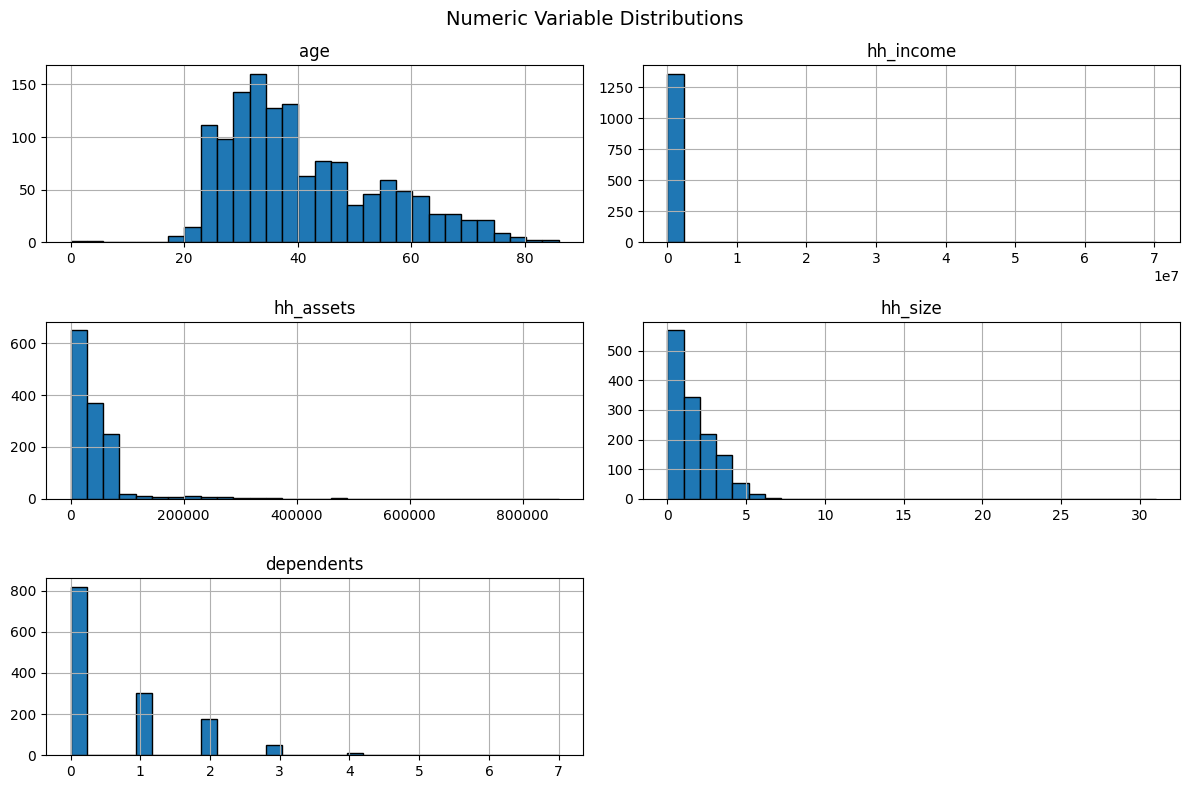

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['age', 'hh_income', 'hh_assets', 'hh_size', 'dependents']

df[numeric_cols].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle('Numeric Variable Distributions', fontsize=14)
plt.tight_layout()
plt.show()

### Numeric Variable Distributions

- **Age:** Mostly between 25–55 years, mean ≈ 40; one invalid record (age = 0).
- **Household Size:** Predominantly 1–3 members; one outlier (31) likely erroneous.
- **Dependents:** Majority with 0–1 dependents, confirming smaller family sizes.
- **Household Income:** Median ≈ $65k; heavy right skew with unrealistic high outliers (~$70M).
- **Household Assets:** Right-skewed; most below $50k, consistent with moderate-income profiles.

*Summary:* Numeric distributions confirm that CHAPA applicants are mostly small households, working-age adults, and moderate-income earners — fitting the target profile for affordable homeownership programs.


In [99]:
def clean_strings(df):
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().str.replace('–', '-', regex=False)
    return df

df = clean_strings(df)


===== RACE_COMBINATION_NORMALIZED =====

📊 Frequency distribution:
race_combination_normalized
White                                                666
Black or African American                            187
Hispanic or Latino                                   149
Asian                                                130
Choose not to answer                                  51
Asian, Pacific Islander or Native Hawaiian            44
Middle Eastern or North African                       34
Black or African American, Hispanic or Latino         26
Hispanic or Latino, White                             23
Black or African American, White                      11
Middle Eastern or North African, White                 7
Asian, White                                           6
Native American or Alaskan Native                      4
Asian, Pacific Islander or Native Hawaiian, White      4
Missing                                                3
Name: count, dtype: int64

💵 Median Household Inc

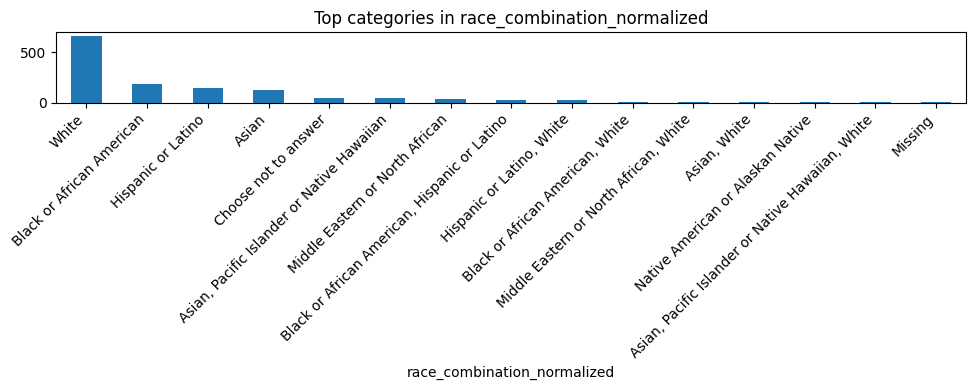


===== HH_TYPE_STANDARDIZED =====

📊 Frequency distribution:
hh_type_standardized
Single person                                    630
Married/partners/couple, no dependents           412
Single parent                                    275
More than one related adults, with dependents     17
Other                                             13
More than one related adults, no dependents       10
Married/partners/couple, with dependents           2
Name: count, dtype: int64

💵 Median Household Income by hh_type_standardized
hh_type_standardized
More than one related adults, with dependents    75000.0
Married/partners/couple, no dependents           72116.5
Married/partners/couple, with dependents         70480.0
Single parent                                    66838.8
More than one related adults, no dependents      66444.2
Single person                                    61000.0
Other                                            60000.0
Name: hh_income, dtype: float64


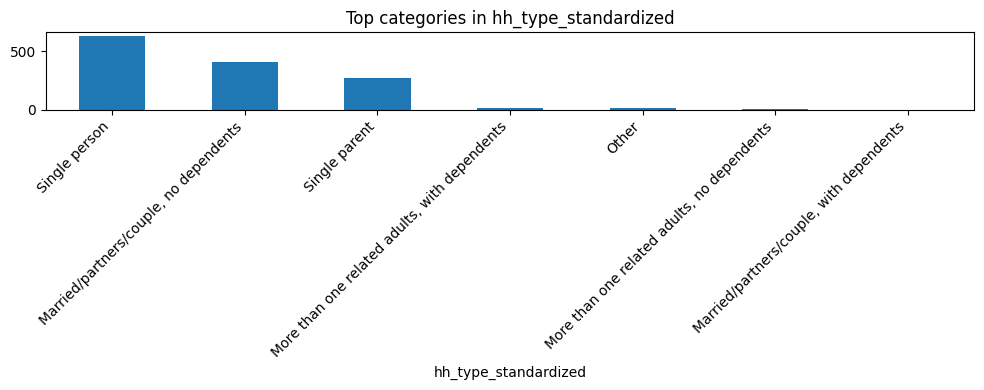


===== MSA =====

📊 Frequency distribution:
msa
Boston-Cambridge-Newton, MA-NH      784
Worcester, MA                       457
Providence-Warwick, RI-MA            63
Amherst Town-Northampton, MA         20
N/A: Dukes County Vineyard Haven     18
Barnstable Town, MA                  17
Name: count, dtype: int64

💵 Median Household Income by msa
msa
Providence-Warwick, RI-MA           73500.00
Barnstable Town, MA                 67200.00
Boston-Cambridge-Newton, MA-NH      67184.31
Worcester, MA                       61393.71
N/A: Dukes County Vineyard Haven    58183.00
Amherst Town-Northampton, MA        55000.00
Name: hh_income, dtype: float64


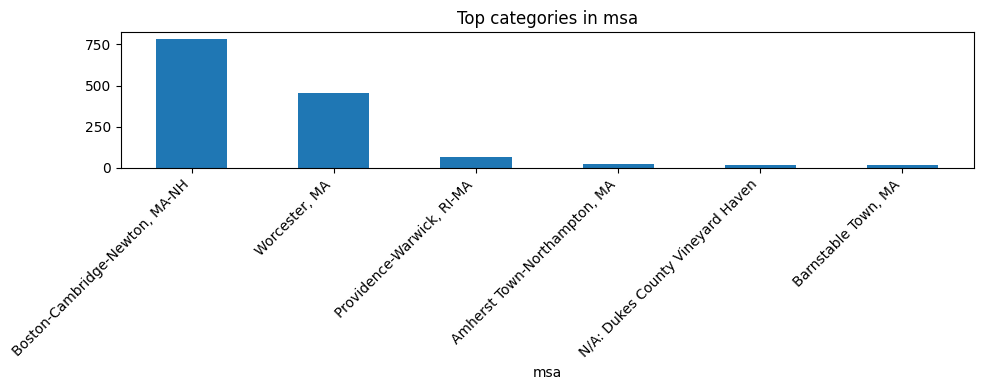


===== MATCH_STATUS =====

📊 Frequency distribution:
match_status
Match       1209
No_Match     150
Name: count, dtype: int64

💵 Median Household Income by match_status
match_status
Match       65558.0
No_Match    59950.0
Name: hh_income, dtype: float64


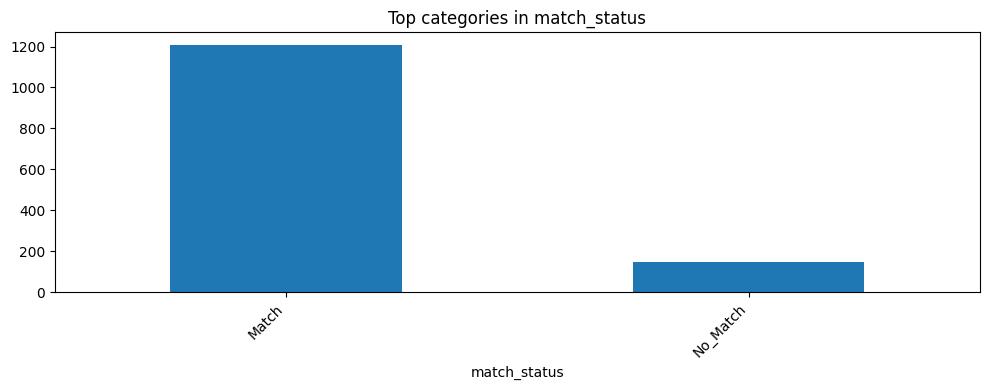


===== FTHB_CLASS? =====

📊 Frequency distribution:
fthb_class?
No         746
Yes        610
Unknown      3
Name: count, dtype: int64

💵 Median Household Income by fthb_class?
fthb_class?
Unknown    73000.0
Yes        67237.3
No         63478.5
Name: hh_income, dtype: float64


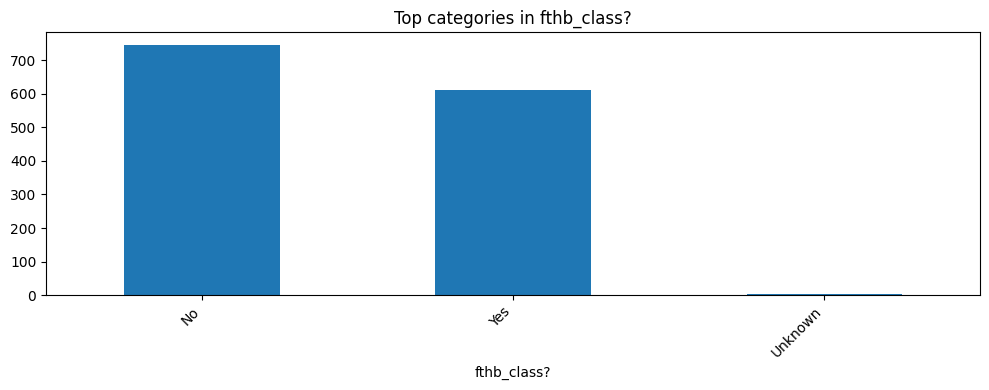

In [100]:
categorical_cols_summary = [
    'race_combination_normalized',
    'hh_type_standardized',
    'msa',
    'match_status',
    'fthb_class?'
]

for col in categorical_cols_summary:
    print(f"\n===== {col.upper()} =====")
    
    # 📊 Frequency distribution
    counts = df[col].value_counts(dropna=False)
    print("\n📊 Frequency distribution:")
    print(counts.head(15)) 
    
    # 💵 Median Household Income by category
    if 'hh_income' in df.columns:
        income_summary = (
            df.groupby(col)['hh_income']
            .median()
            .sort_values(ascending=False)
        )
        print("\n💵 Median Household Income by", col)
        print(income_summary.head(15))
    
    # Bar plot of frequencies
    plt.figure(figsize=(10, 4))
    counts.head(15).plot(kind='bar')
    plt.title(f"Top categories in {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Key Categorical Insights

| Variable | Major Patterns | Notable Income Trends |
|-----------|----------------|------------------------|
| **Race Combination Normalized** | White (49%), Black (14%), Hispanic (11%), Asian (10%) | Asian & multi-racial applicants show higher medians (~$95 k–$100 k); Black & Hispanic lower (~$66 k) |
| **Household Type** | Singles dominate (46%), couples no dependents (30%), single parents (20%) | Larger or dual-adult households earn more |
| **MSA** | Boston (57%), Worcester (34%) | Reflects property distribution; geographic concentration |
| **Match Status** | 89 % matched addresses | Reliable geocoding for spatial analysis |
| **FTHB Class?** | 45 % Yes, 54 % No | Participants slightly lower income; program reaching target audience |

✅ *Summary:* The 2023–25 dataset shows CHAPA’s affordable-housing applicants are primarily small, mid-income, urban households—demographically similar to prior years but still marked by racial income disparities and regional concentration around Boston/Worcester.


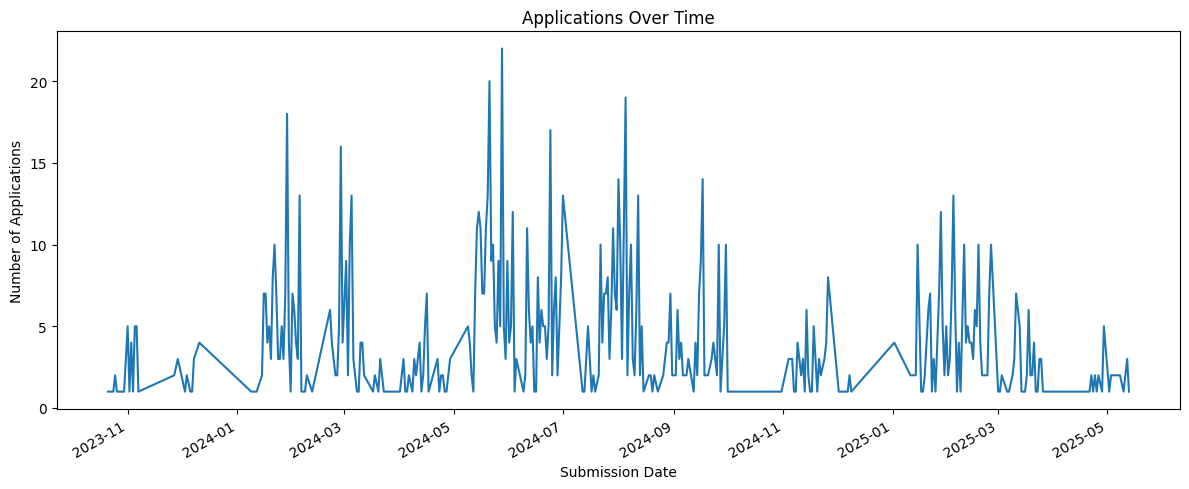

In [101]:
plt.figure(figsize=(12,5))
df['submission_date'].value_counts().sort_index().plot()
plt.title('Applications Over Time')
plt.xlabel('Submission Date')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

### Application Volume Over Time

- **Pattern:** Strong seasonal and event-based peaks, especially between March–July 2024.  
- **Trend:** Consistent interest throughout the 2023–25 period, with quieter intervals after mid-2024.  
- **Interpretation:** Submission spikes correspond to specific property openings or marketing pushes rather than steady inflow.  


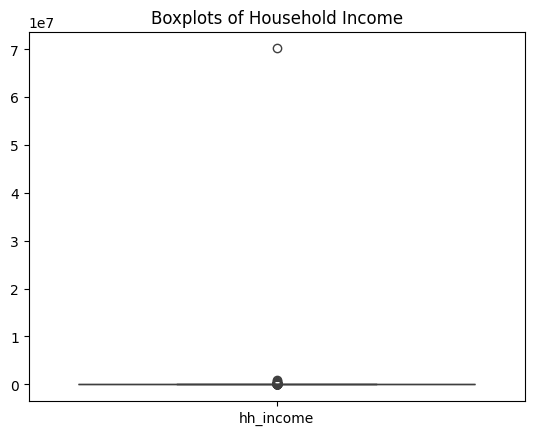

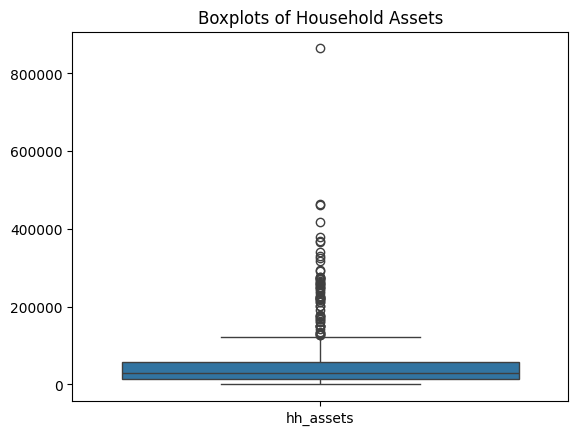

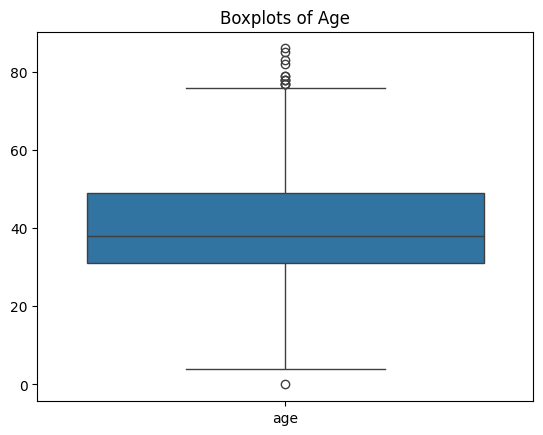

In [102]:
sns.boxplot(data=df[['hh_income']])
plt.title('Boxplots of Household Income')
plt.show()

sns.boxplot(data=df[['hh_assets']])
plt.title('Boxplots of Household Assets')
plt.show()

sns.boxplot(data=df[['age']])
plt.title('Boxplots of Age')
plt.show()

### Numeric Outlier Review

| Variable | Distribution Shape | Outlier Insight |
|-----------|-------------------|-----------------|
| **hh_income** | Highly right-skewed | One extreme outlier (~$70M) far above the normal range; typical values under $200K |
| **hh_assets** | Right-skewed | Several high-value outliers (> $400K), most applicants below $100K |
| **age** | Fairly normal | Concentrated between 30–55 years; a few outliers below 18 or above 85 |

*Summary:* Income and assets are heavily right-skewed due to a few extreme values, while age shows a realistic demographic spread centered around working-age adults.



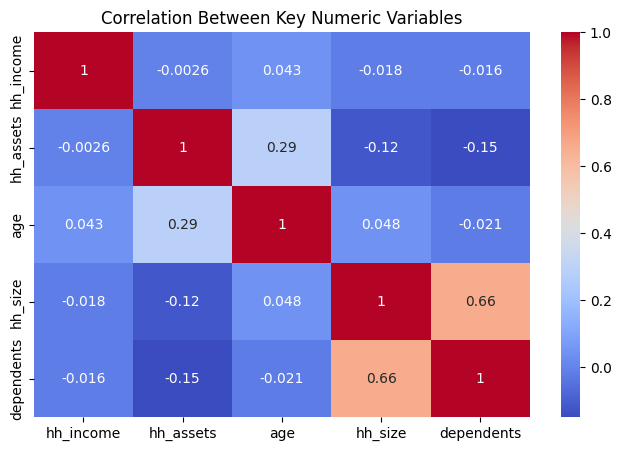

In [103]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['hh_income', 'hh_assets', 'age', 'hh_size', 'dependents']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Key Numeric Variables')
plt.show()

### Correlation Insights

- **Household size and dependents (r = 0.66)** show a strong positive relationship, confirming that larger households naturally include more dependents.  
- **Age and assets (r ≈ 0.29)** have a mild correlation, suggesting that older applicants tend to possess slightly more financial assets.  
- **Income** appears largely uncorrelated with other numeric variables, implying that household earnings are influenced by broader external factors beyond household structure.


C:\Users\rohan\AppData\Local\Temp\ipykernel_48692\2755445423.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


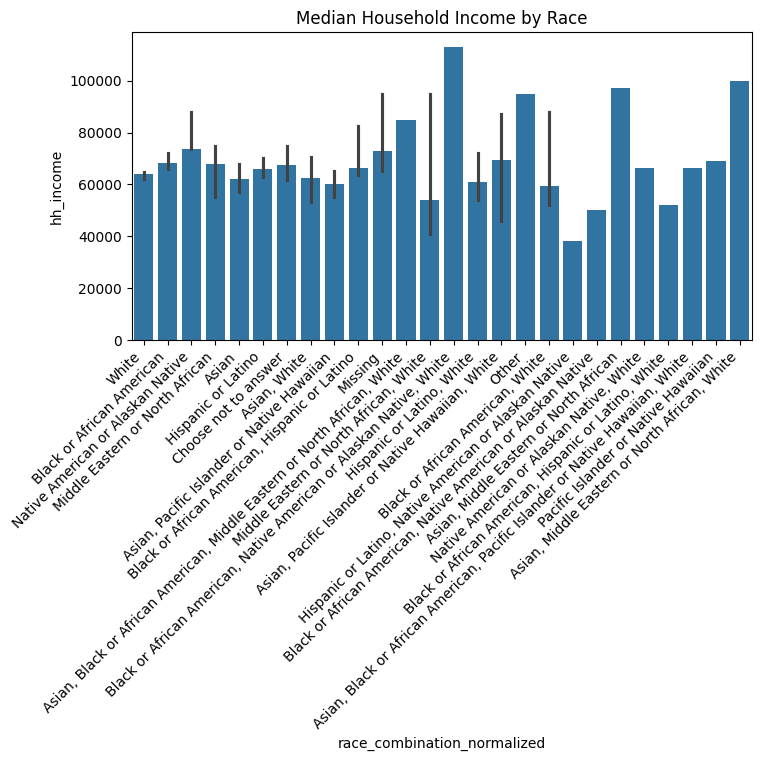

In [104]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='race_combination_normalized', y='hh_income', estimator='median')
plt.xticks(rotation=45, ha='right')
plt.title('Median Household Income by Race')
plt.tight_layout()
plt.show()


### Median Household Income by Race

- Median household income remains around **$60K–$70K** across most racial groups.  
- A few smaller categories (e.g., *mixed-race combinations*) display high variability due to limited sample size.  
- **White** and **Asian** applicants form the largest groups, while **Black or African American** and **Hispanic/Latino** show moderate representation with comparable median income levels.  
- The data hints at **equity parity** across major groups, though sample imbalances may mask subtle disparities.
